In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
%matplotlib widget

db_path = Path('Element_Database.csv')
df = pd.read_csv(db_path)
df.head()


,Unnamed: 0,Atomic Number,Symbol,Name,Atomic Mass [kg],Electron Configuration,Electronegativity [Pauling],Atomic Radius [m],Ionization Energy [eV],Electron Affinity [eV],...,Vapor Ref Temperatures [K],Vapor Ref Pressures [Pa],Molar Mass [kg/mol],R_sp [J/kg/K],Heat Capacity [J/kg/K],Heat of Vaporization [J/kg],Heat of Fusion [J/kg],Clausius Constant,Clausius Errors,T(1 Torr) [K]
0,0,1,H,Hydrogen,1.673784e-27,1s1,2.20,1.200000e-10,13.598,0.754,...,"[15.0, 20.0]","[10000.0, 100000.0]",0.001008,8248.376135,14304.0,4.216398e+05,5.803747e+04,12.618201,"[8.881784197001252e-16, -0.7655750789653909]",6.616834
1,1,2,He,Helium,6.646317e-27,1s2,NaN,1.400000e-10,24.587,NaN,...,"[3.0, 4.0]","[10000.0, 100000.0]",0.004002,2077.240580,5193.0,2.071216e+04,3.447863e+03,12.534007,"[8.881784197001252e-16, -0.7704578164697877]",1.304893
2,2,3,Li,Lithium,1.162350e-26,[He]2s1,0.98,1.820000e-10,5.392,0.618,...,"[797.0, 885.0, 995.0, 1144.0, 1337.0, 1610.0]","[1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0]",0.007000,1187.766163,3582.0,1.942916e+07,4.285844e+05,21.001319,"[0.6115378956801831, 0.2403843392574827, -0.04...",1015.468799
3,3,4,Be,Beryllium,1.496473e-26,[He]2s2,1.57,1.530000e-10,9.323,NaN,...,"[1462.0, 1608.0, 1791.0, 2023.0, 2327.0, 2742.0]","[1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0]",0.009012,922.569276,1825.0,3.240157e+07,8.760629e+05,24.190653,"[0.18302247761812818, 0.047746991702939834, -0...",1819.940962
4,4,5,B,Boron,1.795001e-26,[He]2s2 2p1,2.04,1.920000e-10,8.298,0.277,...,"[2348.0, 2562.0, 2822.0, 3141.0, 3545.0, 4072.0]","[1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0]",0.010810,769.136276,1026.0,4.699495e+07,4.643989e+06,26.247495,"[0.25225814550189884, 0.10074521652213853, -0....",2861.237111


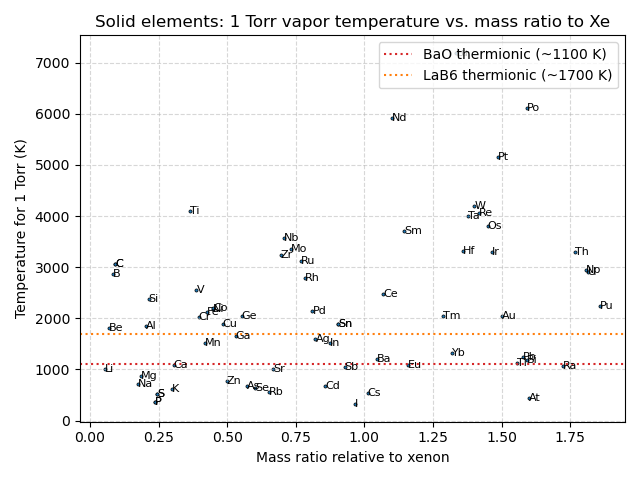

In [7]:
xe_mass = df.loc[df['Symbol'] == 'Xe', 'Atomic Mass [kg]'].squeeze()
solids = df[df['Standard State'].str.strip().str.lower() == 'solid'].copy()
solids = solids[solids['T(1 Torr) [K]'].notna()]
solids['Mass Ratio to Xe'] = solids['Atomic Mass [kg]'] / xe_mass
solids.sort_values('Mass Ratio to Xe', inplace=True)

fig, ax = plt.subplots()
ax.scatter(solids['Mass Ratio to Xe'], solids['T(1 Torr) [K]'], s=5, color='tab:blue', edgecolor='black', linewidth=0.5)
for _, row in solids.iterrows():
    ax.text(row['Mass Ratio to Xe'], row['T(1 Torr) [K]'], row['Symbol'], fontsize=8, ha='left', va='center')

ax.axhline(1100, linestyle=':', color='tab:red', label='BaO thermionic (~1100 K)')
ax.axhline(1700, linestyle=':', color='tab:orange', label='LaB6 thermionic (~1700 K)')

ax.set_xlabel('Mass ratio relative to xenon')
ax.set_ylabel('Temperature for 1 Torr (K)')
ax.set_title('Solid elements: 1 Torr vapor temperature vs. mass ratio to Xe')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()
